<a href="https://colab.research.google.com/github/himanshusar123/-Machine-Learning-Quiz-Classification-or-Regression-/blob/main/Hyperparameter_Tuning2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Advanced_Bank_Loan_Default_XGBoost (1).csv to Advanced_Bank_Loan_Default_XGBoost (1).csv


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "Advanced_Bank_Loan_Default_XGBoost (1).csv"
)

df.head()

,Customer_Age,Annual_Income,Credit_Score,Loan_Amount,Employment_Years,Existing_Loans,Missed_Payments_Last_Year,Credit_Card_Utilization,Debt_To_Income_Ratio,Savings_Balance,Loan_Default
0,56,1850824,528,2282126,33,6,1,70,33.80,1472634,Yes
1,69,2119396,643,346508,7,1,10,84,39.62,226405,Yes
2,46,1271177,379,1066487,6,4,9,8,25.39,1013530,Yes
3,32,1235811,652,2290244,12,1,4,38,25.56,676726,No
4,60,2708388,695,291472,20,1,3,9,9.64,1936898,No


In [4]:
df.shape

(5000, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Customer_Age               5000 non-null   int64  
 1   Annual_Income              5000 non-null   int64  
 2   Credit_Score               5000 non-null   int64  
 3   Loan_Amount                5000 non-null   int64  
 4   Employment_Years           5000 non-null   int64  
 5   Existing_Loans             5000 non-null   int64  
 6   Missed_Payments_Last_Year  5000 non-null   int64  
 7   Credit_Card_Utilization    5000 non-null   int64  
 8   Debt_To_Income_Ratio       5000 non-null   float64
 9   Savings_Balance            5000 non-null   int64  
 10  Loan_Default               5000 non-null   object 
dtypes: float64(1), int64(9), object(1)
memory usage: 429.8+ KB


In [6]:
df.describe()


,Customer_Age,Annual_Income,Credit_Score,Loan_Amount,Employment_Years,Existing_Loans,Missed_Payments_Last_Year,Credit_Card_Utilization,Debt_To_Income_Ratio,Savings_Balance
count,5000.000000,5.000000e+03,5000.0000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5.000000e+03
mean,46.148600,1.606946e+06,602.5920,1.268240e+06,17.022200,3.520800,5.622800,52.1612,42.309162,9.998074e+05
std,16.325753,8.019431e+05,175.9988,7.083272e+05,10.087798,2.280923,3.432561,27.2065,21.664887,5.747889e+05
min,18.000000,2.002150e+05,300.0000,5.160700e+04,0.000000,0.000000,0.000000,5.0000,5.000000,1.160000e+02
25%,32.000000,9.113980e+05,449.7500,6.549458e+05,8.000000,2.000000,3.000000,29.0000,23.415000,5.031360e+05
50%,46.000000,1.621747e+06,603.0000,1.270762e+06,17.000000,4.000000,6.000000,52.0000,42.560000,1.010156e+06
75%,60.000000,2.300613e+06,758.0000,1.884776e+06,26.000000,6.000000,9.000000,76.0000,60.792500,1.492652e+06
max,74.000000,2.998714e+06,899.0000,2.499842e+06,34.000000,7.000000,11.000000,99.0000,79.980000,1.999836e+06


In [7]:
df["Loan_Default"].value_counts()

,count
Loan_Default,
Yes,4025
No,975


In [8]:
df["Loan_Default"] = df["Loan_Default"].map(
    {
        "No":0,
        "Yes":1
    }
)

In [9]:
X = df.drop(
    "Loan_Default",
    axis=1
)

y = df["Loan_Default"]

In [10]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [11]:
model = XGBClassifier(
    random_state=42
)

model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [12]:
y_pred = model.predict(
    X_test
)

In [13]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    round(
        accuracy*100,
        2
    ),
    "%"
)

Accuracy: 97.0 %


In [14]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[171  16]
 [ 14 799]]


In [15]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.92      0.91      0.92       187
           1       0.98      0.98      0.98       813

    accuracy                           0.97      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.97      0.97      0.97      1000



In [16]:
scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print(scores)

print(
    "Average Score:",
    scores.mean()
)

[0.972 0.969 0.979 0.968 0.971]
Average Score: 0.9718


In [17]:
scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print(scores)

print(
    "Average Score:",
    scores.mean()
)

[0.972 0.969 0.979 0.968 0.971]
Average Score: 0.9718


In [18]:
param_grid = {
    "n_estimators":[50,100,200],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.05,0.1]
}

In [19]:
grid = GridSearchCV(
    XGBClassifier(
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(
    X_train,
    y_train
)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [20]:
grid.best_params_

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

In [21]:
grid.best_score_

np.float64(0.96825)

In [22]:
best_model = grid.best_estimator_

best_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [23]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":best_model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
6,Missed_Payments_Last_Year,0.294351
2,Credit_Score,0.204372
8,Debt_To_Income_Ratio,0.159821
5,Existing_Loans,0.123237
3,Loan_Amount,0.116679
7,Credit_Card_Utilization,0.023410
0,Customer_Age,0.022530
9,Savings_Balance,0.019491
1,Annual_Income,0.018912
4,Employment_Years,0.017197


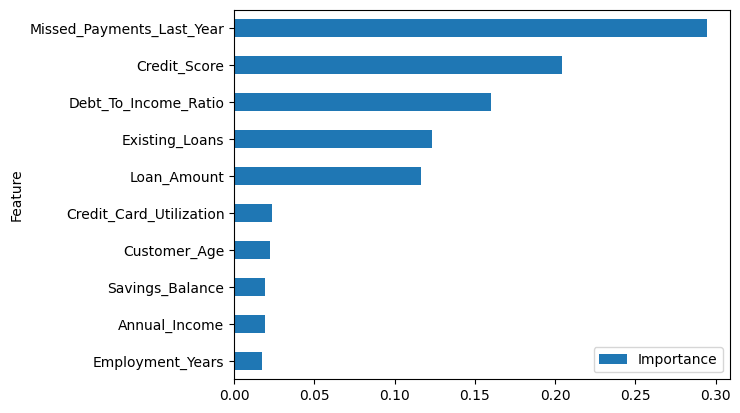

In [24]:
importance.sort_values(
    by="Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.show()

In [25]:
import pickle

pickle.dump(
    best_model,
    open(
        "loan_default_model.pkl",
        "wb"
    )
)

In [26]:
from google.colab import files

files.download(
    "loan_default_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
!pip install gradio

In [29]:
import gradio as gr

app = gr.Interface(
    fn=predict,

    inputs=[
        gr.Slider(18,80,label="Age"),
        gr.Number(label="Annual Income"),
        gr.Slider(300,900,label="Credit Score"),
        gr.Number(label="Loan Amount"),
        gr.Slider(0,40,label="Employment Years"),
        gr.Slider(0,10,label="Existing Loans"),
        gr.Slider(0,20,label="Missed Payments"),
        gr.Slider(0,100,label="Credit Card Utilization"),
        gr.Slider(0,100,label="Debt To Income Ratio"),
        gr.Number(label="Savings Balance")
    ],

    outputs=gr.Textbox(label="Risk Prediction"),

    title="Bank Loan Default Prediction System",

    description="Predict whether a customer is likely to default on a loan."
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a44eb7720f469f195d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
